In [8]:
import matplotlib.pyplot as plt
import numpy as np

n = 1000
p = 800
l =  10

In [9]:
X = np.random.rand(n, p)
Y = np.random.rand(n, l)
lambda_ = 1e-3



In [10]:
beta = np.linalg.solve(X.T @ X, X.T @ Y)
beta_cal = np.linalg.inv(X.T @ X) @ X.T @ Y
print(np.allclose(beta, beta_cal))
beta

True


array([[-0.05108121,  0.10517028, -0.10322308, ...,  0.05377576,
         0.0507025 , -0.0172298 ],
       [ 0.04790677,  0.01511009,  0.02738268, ...,  0.05543143,
        -0.13444495, -0.07702217],
       [ 0.06061621, -0.1408304 , -0.05649078, ...,  0.06023331,
         0.04899191,  0.09929733],
       ...,
       [-0.04309822, -0.1602911 ,  0.01508374, ...,  0.06006273,
         0.03609589,  0.11742444],
       [-0.06021429, -0.1798338 , -0.01652039, ...,  0.02691335,
        -0.05260317, -0.06333086],
       [-0.09599102, -0.02962107, -0.08553805, ..., -0.01125202,
        -0.12733901,  0.03526724]], shape=(800, 10))

In [11]:
ridge_beta_cal = np.linalg.solve(X.T @ X + lambda_ * np.eye(X.shape[1]), X.T @ Y)
ridge_beta_cal

array([[-0.05106713,  0.10514911, -0.10320722, ...,  0.05376497,
         0.05068762, -0.0172412 ],
       [ 0.04788627,  0.01510696,  0.02736996, ...,  0.05538647,
        -0.13437969, -0.07699988],
       [ 0.06059527, -0.14082417, -0.05651027, ...,  0.06023072,
         0.04893925,  0.09926336],
       ...,
       [-0.04309319, -0.16025068,  0.01508568, ...,  0.06003933,
         0.03609242,  0.11738601],
       [-0.06017378, -0.17977912, -0.01653516, ...,  0.02687212,
        -0.05257025, -0.06331005],
       [-0.09595603, -0.02958129, -0.08550784, ..., -0.01117566,
        -0.12726675,  0.03525202]], shape=(800, 10))

In [12]:
import pytest

X_sing = np.c_[X, X[:, -1]]
display(X_sing)

with pytest.raises(np.linalg.LinAlgError):
    # pass
    np.linalg.solve(X_sing.T @ X_sing, X_sing.T @ Y)

beta_sing = np.linalg.solve(X_sing.T @ X_sing + lambda_ * np.eye(X_sing.shape[1]) , X_sing.T @ Y)


array([[0.18496124, 0.48877787, 0.92726336, ..., 0.19214967, 0.1533917 ,
        0.1533917 ],
       [0.85697237, 0.7097011 , 0.59630815, ..., 0.67435146, 0.69231139,
        0.69231139],
       [0.33418421, 0.99477085, 0.31403591, ..., 0.59573016, 0.94882281,
        0.94882281],
       ...,
       [0.7199919 , 0.82423089, 0.65744433, ..., 0.15906873, 0.71768613,
        0.71768613],
       [0.15006885, 0.76645499, 0.92845298, ..., 0.71759572, 0.54944632,
        0.54944632],
       [0.78187495, 0.4331681 , 0.27570628, ..., 0.69879943, 0.40294366,
        0.40294366]], shape=(1000, 801))

In [13]:
concat_ = np.concatenate([beta_cal.reshape(-1, 1), ridge_beta_cal.reshape(-1, 1)], axis=1)

(array([[  1.,   0.,   1.,   0.,   0.,   2.,   0.,   6.,   8.,  14.,  25.,
          44.,  69., 106., 148., 215., 276., 361., 425., 526., 561., 602.,
         635., 660., 631., 571., 498., 418., 359., 238., 194., 127., 121.,
          51.,  53.,  27.,  15.,   7.,   3.,   2.],
        [  1.,   0.,   1.,   0.,   0.,   2.,   0.,   6.,   8.,  14.,  25.,
          44.,  69., 105., 147., 217., 274., 363., 425., 526., 561., 601.,
         635., 662., 631., 569., 499., 421., 357., 237., 194., 127., 121.,
          51.,  53.,  27.,  15.,   7.,   3.,   2.]]),
 array([-0.32917412, -0.31475764, -0.30034115, -0.28592467, -0.27150819,
        -0.25709171, -0.24267522, -0.22825874, -0.21384226, -0.19942578,
        -0.18500929, -0.17059281, -0.15617633, -0.14175985, -0.12734336,
        -0.11292688, -0.0985104 , -0.08409392, -0.06967743, -0.05526095,
        -0.04084447, -0.02642799, -0.0120115 ,  0.00240498,  0.01682146,
         0.03123795,  0.04565443,  0.06007091,  0.07448739,  0.08890388,
      

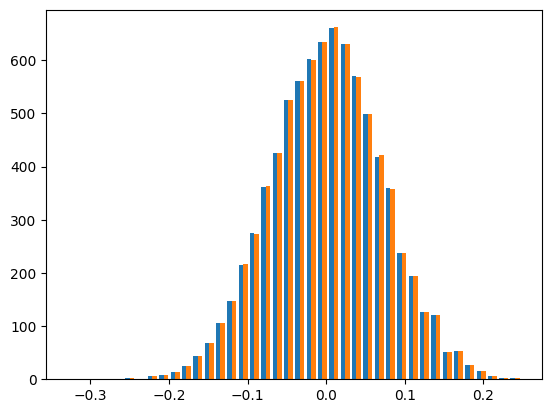

In [14]:
plt.hist(concat_ , bins=40)
# plt.legend()s

In [15]:
import statsmodels.api as sm 
import numpy as np

model = sm.OLS(Y, X)
results = model.fit()
results.params

array([[-0.05108121,  0.10517028, -0.10322308, ...,  0.05377576,
         0.0507025 , -0.0172298 ],
       [ 0.04790677,  0.01511009,  0.02738268, ...,  0.05543143,
        -0.13444495, -0.07702217],
       [ 0.06061621, -0.1408304 , -0.05649078, ...,  0.06023331,
         0.04899191,  0.09929733],
       ...,
       [-0.04309822, -0.1602911 ,  0.01508374, ...,  0.06006273,
         0.03609589,  0.11742444],
       [-0.06021429, -0.1798338 , -0.01652039, ...,  0.02691335,
        -0.05260317, -0.06333086],
       [-0.09599102, -0.02962107, -0.08553805, ..., -0.01125202,
        -0.12733901,  0.03526724]], shape=(800, 10))

800 cholesky


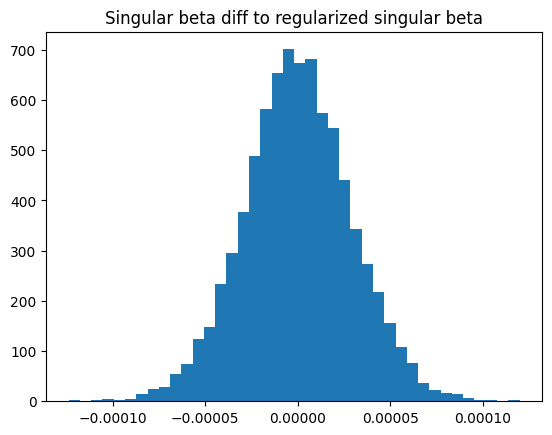

In [16]:
from sklearn.linear_model import LinearRegression, Ridge

reg = LinearRegression(fit_intercept=False).fit(X, Y)
reg_sing = LinearRegression(fit_intercept=False).fit(X_sing, Y)
assert np.allclose(beta, reg.coef_.T)
sing_same = np.allclose(beta_sing, reg_sing.coef_.T)
if not sing_same:
    import matplotlib.pyplot as plt
    img = plt.hist((beta_sing - reg_sing.coef_.T).reshape(-1), bins=40)
    plt.title('Singular beta diff to regularized singular beta')
    # display(img)
ridge_reg_sing = Ridge(alpha=lambda_, fit_intercept=False).fit(X_sing, Y)
assert np.allclose(beta_sing, ridge_reg_sing.coef_.T)
print(reg.rank_, ridge_reg_sing.solver_)

In [ ]:
X

residuals no-intercept: -0.01366189497153103
residuals has-intercept: 2.0691723889854075e-08
residuals has-intercept: -1.7968509140597888e-05
coef sum: 10.4199647907961
coef ridge sum: 10.419192252691186


Text(0.5, 1.0, 'Residuals cummean sum axis-1')

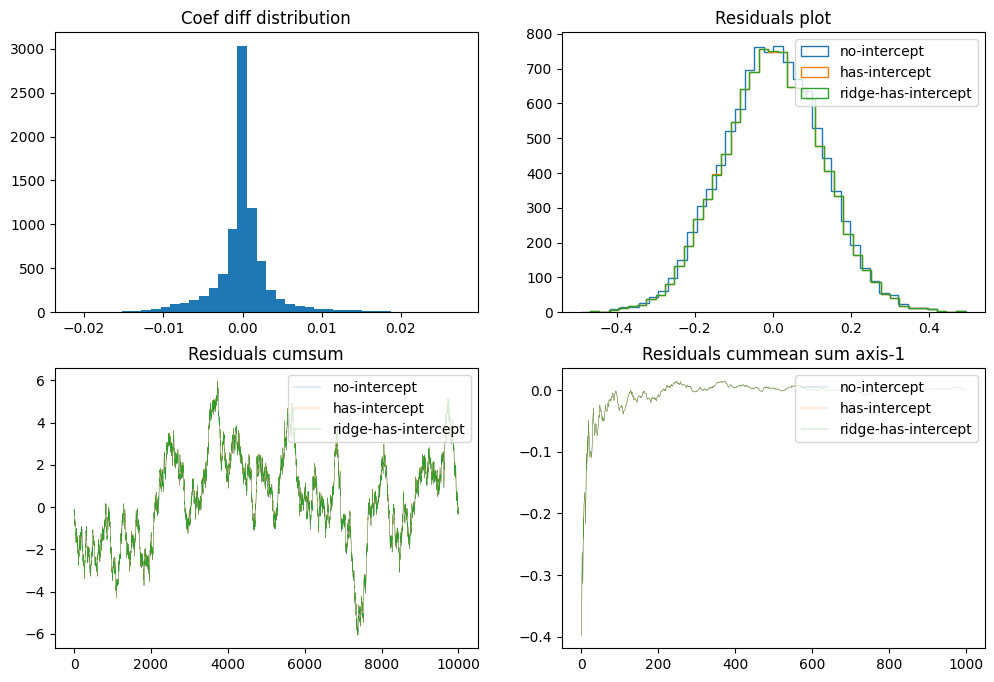

In [68]:
# Y = X @ beta + error
X_int = np.c_[np.ones(X.shape[0]).reshape(-1, 1), X]
# X_int
beta_int = np.linalg.inv(X_int.T @ X_int) @ X_int.T @ Y
intercept = beta_int[0, :]
coef_int = beta_int[1:, :]

beta_ridge_int = np.linalg.inv(X_int.T @ X_int + np.identity(X_int.shape[1]) * 1e-4) @ X_int.T @ Y
ridge_intercept = beta_ridge_int[0, :]
coef_ridge_int = beta_ridge_int[1:, :]
# display(coef_int, intercept, beta)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))  # 800px x 600px at default 100dpi
ax[0][0].hist((coef_int - beta).reshape(-1, 1), bins=40)
ax[0][0].set_title('Coef diff distribution')



residuals_no_intercept = Y - X @ beta
residuals_has_intercept = Y - X @ coef_int - intercept
residuals_ridge_has_intercept = Y - X @ coef_ridge_int - ridge_intercept
print(f'residuals no-intercept: {np.sum(residuals_no_intercept)}')
print(f'residuals has-intercept: {np.sum(residuals_has_intercept)}')
print(f'residuals has-intercept: {np.sum(residuals_ridge_has_intercept)}')

print(f'coef sum: {np.sum(coef_int)}')
print(f'coef ridge sum: {np.sum(coef_ridge_int)}')

ax[0][1].hist(residuals_no_intercept.reshape(-1, 1), bins=40, histtype='step', label='no-intercept')
ax[0][1].hist(residuals_has_intercept.reshape(-1, 1), bins=40, histtype='step', label='has-intercept')
ax[0][1].hist(residuals_ridge_has_intercept.reshape(-1, 1), bins=40, histtype='step', label='ridge-has-intercept')
ax[0][1].legend(loc='upper right')
ax[0][1].set_title('Residuals plot')

ax[1][0].plot(np.cumsum(residuals_no_intercept).reshape(-1, 1), label='no-intercept', linewidth=.2)
ax[1][0].plot(np.cumsum(residuals_has_intercept).reshape(-1, 1), label='has-intercept', linewidth=.2)
ax[1][0].plot(np.cumsum(residuals_ridge_has_intercept).reshape(-1, 1), label='ridge-has-intercept', linewidth=.2)
ax[1][0].legend(loc='upper right')
ax[1][0].set_title('Residuals cumsum')


ax[1][1].plot(np.cumsum(residuals_no_intercept.sum(axis=1)) / np.arange(1, n+1), label='no-intercept', linewidth=.2)
ax[1][1].plot(np.cumsum(residuals_has_intercept.sum(axis=1)) / np.arange(1, n+1), label='has-intercept', linewidth=.2)
ax[1][1].plot(np.cumsum(residuals_ridge_has_intercept.sum(axis=1)) / np.arange(1, n+1), label='ridge-has-intercept', linewidth=.2)
ax[1][1].legend(loc='upper right')
ax[1][1].set_title('Residuals cummean sum axis-1')
# beta_intercept = ()